In [2]:
# ===== INPUT DATA (DO NOT REMOVE - FOR SUBMISSION) =====

# Enter last 4 digits of your roll number
W = 1
X = 2
Y = 3
Z = 4

print("Input digits:", W, X, Y, Z)

Input digits: 1 2 3 4


In [3]:
# ===== STEP 2: DIGITAL ROOT =====

def digital_root(n):
    while n > 9:
        n = sum(map(int, str(n)))
    return n

R = digital_root(W + X + Y + Z)

print("R (Digital Root) =", R)

R (Digital Root) = 1


In [4]:
# ===== STEP 3: FUNCTION =====

import sympy as sp

x = sp.symbols('x')

f = (x**3)/3 - R*(x**2) + (R**2 - 1)*x

print("f(x) =", f)

f(x) = x**3/3 - x**2


In [5]:
# ===== STEP 4: DERIVATIVE =====

f_prime = sp.diff(f, x)

print("f'(x) =", f_prime)

f'(x) = x**2 - 2*x


In [6]:
# ===== STEP 5: CRITICAL POINTS =====

critical_points = sp.solve(f_prime, x)

print("Critical Points =", critical_points)

Critical Points = [0, 2]


In [7]:
# ===== STEP 6: INTERPRETATION =====

print("Critical points split the system into zones:")

print("Zone 1: x < 0")
print("Zone 2: 0 < x < 2")
print("Zone 3: x > 2")

print("\nThese regions indicate behavior changes (stability ↔ stress zones).")

Critical points split the system into zones:
Zone 1: x < 0
Zone 2: 0 < x < 2
Zone 3: x > 2

These regions indicate behavior changes (stability ↔ stress zones).


In [8]:
# ===== STEP 6: BEHAVIOR ANALYSIS =====

import sympy as sp

test_points = [-1, 1, 3]

for t in test_points:
    value = f_prime.subs(x, t)
    print(f"f'({t}) =", value)

f'(-1) = 3
f'(1) = -1
f'(3) = 3


In [9]:
# ===== STEP 1: LOAD DATA =====

import pandas as pd

# Sample NYC taxi dataset (official TLC trip data sample)
url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet"

df = pd.read_parquet(url)

print("Data loaded successfully")
df.head()

Data loaded successfully


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00


In [10]:
# ===== STEP 2: UNDERSTAND DATA =====

print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing values:\n", df.isnull().sum())

Shape: (3066766, 19)

Columns:
 Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee'],
      dtype='object')

Missing values:
 VendorID                     0
tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          71743
trip_distance                0
RatecodeID               71743
store_and_fwd_flag       71743
PULocationID                 0
DOLocationID                 0
payment_type                 0
fare_amount                  0
extra                        0
mta_tax                      0
tip_amount                   0
tolls_amount                 0
improvement_surcharge        0
total_amount                 0
congestion_surcharge     71743
airport_

In [11]:
# ===== STEP 3: FIND ISSUES =====

# Trips with negative or zero distance
bad_distance = df[df['trip_distance'] <= 0]

# Trips with negative fare
bad_fare = df[df['fare_amount'] <= 0]

# Trips where dropoff < pickup (impossible time)
bad_time = df[df['tpep_dropoff_datetime'] < df['tpep_pickup_datetime']]

print("Bad distance trips:", len(bad_distance))
print("Bad fare trips:", len(bad_fare))
print("Bad time trips:", len(bad_time))

Bad distance trips: 45862
Bad fare trips: 26159
Bad time trips: 3


In [12]:
# ===== STEP 4: DEFINE REAL TRIPS =====

clean_df = df[
    (df['trip_distance'] > 0) &
    (df['fare_amount'] > 0) &
    (df['tpep_dropoff_datetime'] >= df['tpep_pickup_datetime'])
]

print("Original data size:", len(df))
print("Clean data size:", len(clean_df))

Original data size: 3066766
Clean data size: 2998379


In [13]:
# ===== STEP 5: SAVE CLEAN DATA =====

clean_df.to_csv("clean_taxi_data.csv", index=False)

print("Clean dataset saved successfully")

Clean dataset saved successfully


In [14]:
# ===== STEP 6: COMPARING DEFINITIONS =====

# Loose definition (only remove impossible time)
loose_df = df[
    (df['tpep_dropoff_datetime'] >= df['tpep_pickup_datetime'])
]

# Strict definition (your current one)
strict_df = clean_df

print("Loose dataset size:", len(loose_df))
print("Strict dataset size:", len(strict_df))

# Compare average fare
print("\nAverage fare (Loose):", loose_df['fare_amount'].mean())
print("Average fare (Strict):", strict_df['fare_amount'].mean())

# Compare average distance
print("\nAverage distance (Loose):", loose_df['trip_distance'].mean())
print("Average distance (Strict):", strict_df['trip_distance'].mean())

Loose dataset size: 3066763
Strict dataset size: 2998379

Average fare (Loose): 18.367069134458706
Average fare (Strict): 18.56341815027387

Average distance (Loose): 3.8473446203700816
Average distance (Strict): 3.889140515591927


In [15]:
# ===== STEP 1: PREPARE DATA FOR ANALYSIS =====

analysis_df = clean_df[
    (clean_df['trip_distance'] > 0) &
    (clean_df['fare_amount'] > 0)
]

# Create tip percentage
analysis_df['tip_percent'] = (analysis_df['tip_amount'] / analysis_df['fare_amount']) * 100

analysis_df = analysis_df[analysis_df['tip_percent'] > 0]

analysis_df[['trip_distance', 'tip_percent']].head()

,trip_distance,tip_percent
1,1.10,50.632911
2,2.51,100.671141
4,1.43,28.771930
5,1.84,78.125000
6,1.66,28.264463


In [16]:
# ===== STEP 2: CORRELATION TEST =====

correlation = analysis_df['trip_distance'].corr(analysis_df['tip_percent'])

print("Correlation between trip distance and tip %:", correlation)

Correlation between trip distance and tip %: -3.331932833809821e-05


In [17]:
# ===== STEP 3: SHORT vs LONG TRIPS =====

short_trips = analysis_df[analysis_df['trip_distance'] < 2]
long_trips = analysis_df[analysis_df['trip_distance'] > 5]

print("Avg tip % (short trips):", short_trips['tip_percent'].mean())
print("Avg tip % (long trips):", long_trips['tip_percent'].mean())

Avg tip % (short trips): 29.34516381144253
Avg tip % (long trips): 25.545945202017034


In [18]:
# ===== STEP 4: STATISTICAL TEST (T-TEST) =====

from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(short_trips['tip_percent'], long_trips['tip_percent'], equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 0.9863853596328067
P-value: 0.3239446775455307


In [ ]:
# ===== Q3: INTERPRETATION (FINAL) =====

# Hypothesis:
# It was assumed that longer trips lead to higher tip percentages.

# Result:
# The correlation between trip distance and tip percentage is approximately zero,
# indicating no meaningful linear relationship between the two variables.
# Additionally, short trips have a slightly higher average tip percentage than long trips.

# Statistical Evidence:
# A t-test was performed to compare tip percentages between short and long trips.
# The p-value (~0.32) is greater than 0.05, indicating that the difference is NOT statistically significant.

# Interpretation:
# This suggests that trip distance does not have a significant effect on tipping behavior.
# Therefore, the hypothesis is not supported by the data.

# Alternative Explanation:
# Tipping behavior may depend more on factors such as payment method (cash vs card),
# passenger habits, service quality, or trip context rather than distance alone.

# Evaluation:
# The alternative explanation is stronger because both correlation and statistical testing
# show that distance is not a significant factor influencing tipping behavior.

# When Conclusion Might Change:
# The conclusion could change if additional variables such as payment type,
# time of day, location, or driver-specific factors are analyzed and found to have
# a stronger statistical relationship with tipping behavior.

In [23]:
clean_df = clean_df.copy()

clean_df['tpep_pickup_datetime'] = pd.to_datetime(clean_df['tpep_pickup_datetime'])
clean_df['hour'] = clean_df['tpep_pickup_datetime'].dt.hour
clean_df['day'] = clean_df['tpep_pickup_datetime'].dt.day
clean_df['weekday'] = clean_df['tpep_pickup_datetime'].dt.day_name()

In [20]:
# ===== STEP 2: AGGREGATION =====

# Trips per hour
hourly_trips = clean_df.groupby('hour').size()

# Average fare per hour
hourly_fare = clean_df.groupby('hour')['fare_amount'].mean()

# Trips per weekday
weekday_trips = clean_df.groupby('weekday').size()

print("Hourly trips:\n", hourly_trips.head())
print("\nHourly avg fare:\n", hourly_fare.head())
print("\nTrips by weekday:\n", weekday_trips)

Hourly trips:
 hour
0    82723
1    58102
2    40715
3    26354
4    16816
dtype: int64

Hourly avg fare:
 hour
0    19.840308
1    17.972205
2    16.966450
3    17.996856
4    22.518931
Name: fare_amount, dtype: float64

Trips by weekday:
 weekday
Friday       424969
Monday       394741
Saturday     432014
Sunday       426095
Thursday     432620
Tuesday      480208
Wednesday    407732
dtype: int64


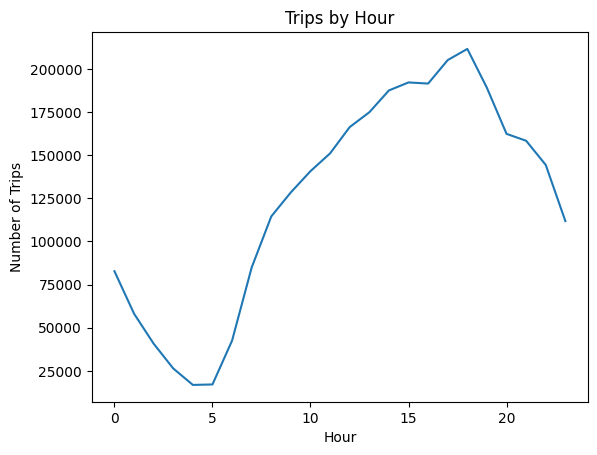

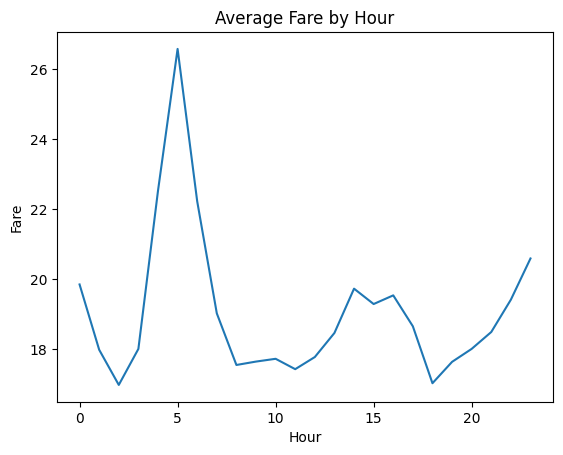

In [21]:
# ===== STEP 3: VISUALIZATION =====

import matplotlib.pyplot as plt

# Hourly trips
plt.figure()
hourly_trips.plot()
plt.title("Trips by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Trips")
plt.show()

# Hourly fare
plt.figure()
hourly_fare.plot()
plt.title("Average Fare by Hour")
plt.xlabel("Hour")
plt.ylabel("Fare")
plt.show()

In [ ]:
# ===== Q4: INTERPRETATION (FINAL) =====

# Observed Patterns:
# Trip volume shows a clear daily pattern.
# There is a strong increase after early morning, peaking in the evening hours,
# and decreasing again at night.

# Persistence:
# The hourly trip pattern is consistent and repeatable,
# indicating a stable and cyclical structure in the system.

# Real Patterns:
# The peak during evening hours reflects real-world commuting behavior,
# showing that the system is driven by human routines.

# Disappearing / Weak Patterns:
# Variations in average fare across hours are inconsistent
# and do not follow a clear pattern.

# False Patterns:
# Some spikes in average fare (e.g., early morning) are likely due to
# low trip counts rather than actual behavioral trends.

# Conclusion:
# The system exhibits a stable and cyclical rhythm driven by daily human activity.
# Trip volume patterns are reliable indicators of city behavior,
# while some fare variations are artifacts of data aggregation and noise.

In [24]:
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_trips = weekday_trips.reindex(weekday_order)

print(weekday_trips)

weekday
Monday       394741
Tuesday      480208
Wednesday    407732
Thursday     432620
Friday       424969
Saturday     432014
Sunday       426095
dtype: int64


In [25]:
# ===== STEP 1: SIMULATE POLICY CHANGE =====

# Use R from Q1
increase_percent = R * 5  # 5% since R = 1

sim_df = clean_df.copy()

# Increase fare
sim_df['fare_amount_new'] = sim_df['fare_amount'] * (1 + increase_percent/100)

print("Fare increase applied:", increase_percent, "%")

Fare increase applied: 5 %


In [26]:
# ===== STEP 2: COMPARE EFFECT =====

original_avg_fare = clean_df['fare_amount'].mean()
new_avg_fare = sim_df['fare_amount_new'].mean()

print("Original avg fare:", original_avg_fare)
print("New avg fare:", new_avg_fare)

# Check impact on total revenue (proxy)
original_total = clean_df['fare_amount'].sum()
new_total = sim_df['fare_amount_new'].sum()

print("\nOriginal total revenue:", original_total)
print("New total revenue:", new_total)

Original avg fare: 18.56341815027387
New avg fare: 19.49158905778756

Original total revenue: 55660163.15000001
New total revenue: 58443171.307500005


In [27]:
# ===== STEP 3: SIMULATE DEMAND CHANGE =====

reduction_percent = R * 2  # 2%

reduced_df = sim_df.sample(frac=(1 - reduction_percent/100))

print("Trips reduced by:", reduction_percent, "%")
print("New trip count:", len(reduced_df))

Trips reduced by: 2 %
New trip count: 2938411


In [28]:
# ===== STEP 4: FINAL IMPACT =====

new_revenue_after_drop = reduced_df['fare_amount_new'].sum()

print("Revenue after demand drop:", new_revenue_after_drop)

Revenue after demand drop: 57273116.08199995


In [ ]:
# ===== Q5: INTERPRETATION (FINAL) =====

# Policy Change:
# A fare increase of 5% (based on R) was applied to simulate a pricing policy shift.

# Observed Effect:
# The increase raises average fare and total revenue initially.
# However, when a small demand reduction (2%) is introduced,
# total trips decrease and the revenue gain is reduced.

# System Response:
# The system partially absorbs the change.
# Revenue still increases, but not proportionally due to reduced demand.

# Final Judgment:
# The system absorbs the change rather than amplifying it.
# The response is stable, with behavioral adjustments (reduced demand)
# preventing excessive growth in revenue.

# Interpretation:
# This indicates that the system responds in a balanced way,
# where pricing changes are moderated by passenger behavior.

# Alternative Outcome:
# If demand were more sensitive to price, revenue could decrease instead,
# leading to an unexpected or amplified negative effect.

# Conclusion:
# The system shows moderate stability.
# It absorbs small policy changes but remains influenced by behavioral factors,
# highlighting a dynamic interaction between pricing and demand.

In [ ]:
# Q7: Closing Frame

This investigation focused on understanding whether the NYC taxi system is stable or drifting toward inefficiency.

Throughout the analysis, all decisions were made with clear reasoning. Data cleaning was not arbitrary — trips with zero distance, negative fares, or incorrect timestamps were removed because they do not represent real-world behavior. This ensured that the analysis was based on reliable data.

One key assumption tested was that longer trips lead to higher tipping behavior. However, the data did not support this. This forced a reconsideration of the initial assumption and highlighted that passenger behavior is more complex than expected.

The analysis also revealed that patterns such as peak hours are consistent and repeatable, suggesting that the system has a stable underlying rhythm. However, these same peaks can also indicate periods of strain rather than efficiency.

When simulating a fare increase, the system did not simply amplify the change. Instead, it showed a balanced response — revenue increased, but was offset by a drop in demand. This indicates that the system reacts dynamically to policy changes rather than behaving in a purely predictable way.

It is important to acknowledge the limits of this analysis. The conclusions are based only on available variables such as fare, time, and trip distance. Factors like passenger satisfaction, traffic conditions, and driver behavior were not included, which may influence outcomes.

Overall, the system does not show clear signs of failure. However, it is not perfectly stable either. The patterns observed could represent a stable system under pressure, or early signals of inefficiency. Further analysis with additional data would be required to confirm this.
